<a href="https://colab.research.google.com/github/FunSumTime/Senior_Project_medical_imaging_detection/blob/main/final_approach_two_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
tf.keras.backend.clear_session()


NameError: name 'tf' is not defined

In [ ]:
# imports
import os
import math
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image

# =========================
# Constants
# =========================
DATA_ROOT ="/content/drive/MyDrive/pneumonia_data"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
VAL_SPLIT = 0.2
SEED = 42
NUM_CLASSES = 2

# optional crop experiment
USE_CENTER_CROP = True
CROP_FRACTION = 0.85

AUTOTUNE = tf.data.AUTOTUNE

TRAIN_DIR = os.path.join(DATA_ROOT, "train")
TEST_DIR = os.path.join(DATA_ROOT, "test")

# Load Data


In [ ]:
# =========================
# Augmentation
# =========================
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.10),
    layers.RandomTranslation(0.05, 0.05),
], name="data_augmentation")
# =========================
# Optional center crop
# =========================
def apply_center_crop(image):
    if not USE_CENTER_CROP:
        return image

    image = tf.image.central_crop(image, central_fraction=CROP_FRACTION)
    image = tf.image.resize(image, IMG_SIZE)
    return image

    # =========================
# Preprocessing
# NOTE:
# do NOT divide by 255 here because EfficientNet preprocessing
# will happen inside the model
# =========================
def preprocess_base(image, label):
    image = tf.cast(image, tf.float32)

    if USE_CENTER_CROP:
        image = apply_center_crop(image)
    else:
        image = tf.image.resize(image, IMG_SIZE)

    return image, label


def preprocess_train(image, label):
    image, label = preprocess_base(image, label)
    image = data_augmentation(image, training=True)
    return image, label

In [ ]:
# =========================
# Load raw datasets
# =========================
train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    validation_split=VAL_SPLIT,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    validation_split=VAL_SPLIT,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

class_names = train_ds_raw.class_names
print("Class names:", class_names)

Found 5233 files belonging to 2 classes.
Using 4187 files for training.
Found 5233 files belonging to 2 classes.
Using 1046 files for validation.
Found 624 files belonging to 2 classes.
Class names: ['NORMAL', 'PNEUMONIA']


In [ ]:
# =========================
# Apply preprocessing
# =========================
train_ds = train_ds_raw.map(preprocess_train, num_parallel_calls=AUTOTUNE)
val_ds = val_ds_raw.map(preprocess_base, num_parallel_calls=AUTOTUNE)
test_ds = test_ds_raw.map(preprocess_base, num_parallel_calls=AUTOTUNE)

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

In [ ]:
# quick checks
print("train spec:", train_ds.element_spec)
print("val spec:", val_ds.element_spec)
print("test spec:", test_ds.element_spec)

for images, labels in train_ds.take(1):
    print("train batch images:", images.shape, images.dtype)
    print("train batch labels:", labels.shape, labels.dtype)

train spec: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))
val spec: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))
test spec: (TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))
train batch images: (32, 224, 224, 3) <dtype: 'float32'>
train batch labels: (32,) <dtype: 'int32'>


# Data set inspection

In [ ]:
def count_labels(ds, class_names):
    counts = {name: 0 for name in class_names}
    for _, labels in ds.unbatch():
        idx = int(labels.numpy())
        counts[class_names[idx]] += 1
    return counts

In [ ]:
train_counts = count_labels(train_ds, class_names)
val_counts = count_labels(val_ds, class_names)
test_counts = count_labels(test_ds, class_names)

print("Train counts:", train_counts)
print("Val counts:", val_counts)
print("Test counts:", test_counts)

KeyboardInterrupt: 

In [ ]:
def show_batch(dataset, class_names, rows=2, cols=4):
    plt.figure(figsize=(12, 6))

    for images, labels in dataset.take(1):
        for i in range(rows * cols):
            plt.subplot(rows, cols, i + 1)

            img = images[i].numpy()
            img = np.clip(img / 255.0, 0.0, 1.0)  # display only

            plt.imshow(img)
            plt.title(class_names[int(labels[i].numpy())])
            plt.axis("off")

    plt.tight_layout()
    plt.show()

print("Training batch preview:")
show_batch(train_ds, class_names)

print("Validation batch preview:")
show_batch(val_ds, class_names)

# Model one Efficientnet

In [ ]:
def build_model1_efficientnet_b0(input_shape=(224, 224, 3), num_classes=2):
    base_model = keras.applications.EfficientNetB0(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    # start frozen
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape, name="image_input")

    # model-specific preprocessing inside model
    x = keras.applications.efficientnet.preprocess_input(inputs)

    # backbone output
    x = base_model(x, training=False)

    # exposed feature map for Grad-CAM
    feat_maps = layers.Lambda(lambda t: t, name="feat_maps")(x)

    # head
    x = layers.GlobalAveragePooling2D(name="gap")(feat_maps)
    x = layers.BatchNormalization(name="bn_head")(x)
    x = layers.Dropout(0.30, name="dropout_1")(x)
    x = layers.Dense(256, activation="gelu", name="dense_256")(x)
    x = layers.Dropout(0.20, name="dropout_2")(x)
    x = layers.Dense(128, activation="gelu", name="dense_128")(x)
    x = layers.Dropout(0.20, name="dropout_3")(x)
    x = layers.Dense(64, activation="gelu", name="dense_64")(x)
    x = layers.Dropout(0.20, name="dropout_4")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = keras.Model(inputs, outputs, name="model1_efficientnetb0")
    return model, base_model

#densenet model

In [ ]:
def build_model1_densenet121(input_shape=(224, 224, 3), num_classes=2):
    base_model = keras.applications.DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )

    # start frozen
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape, name="image_input")

    # DenseNet preprocessing
    x = keras.applications.densenet.preprocess_input(inputs)

    # backbone
    x = base_model(x, training=False)

    # exposed feature maps for Grad-CAM
    feat_maps = layers.Lambda(lambda t: t, name="feat_maps")(x)

    # head
    x = layers.GlobalAveragePooling2D(name="gap")(feat_maps)
    x = layers.BatchNormalization(name="bn_head")(x)
    x = layers.Dropout(0.30, name="dropout_1")(x)
    x = layers.Dense(256, activation="gelu", name="dense_256")(x)
    x = layers.Dropout(0.20, name="dropout_2")(x)
    x = layers.Dense(128, activation="gelu", name="dense_128")(x)
    x = layers.Dropout(0.20, name="dropout_3")(x)
    x = layers.Dense(64, activation="gelu", name="dense_64")(x)
    x = layers.Dropout(0.20, name="dropout_4")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="predictions")(x)

    model = keras.Model(inputs, outputs, name="model1_densenet121")
    return model, base_model

#train densenet


In [ ]:
tf.keras.backend.clear_session()

model2_frozen, base_model = build_model1_densenet121(
    input_shape=(224, 224, 3),
    num_classes=2
)

model2_frozen.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_frozen = model2_frozen.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=20,
            restore_best_weights=True
        )
    ]
)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 248s 1s/step - accuracy: 0.9049 - loss: 0.2251 - val_accuracy: 0.9522 - val_loss: 0.1771
Epoch 2/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 18s 131ms/step - accuracy: 0.9410 - loss: 0.1547 - val_accuracy: 0.9570 - val_loss: 0.1207
Epoch 3/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 128ms/step - accuracy: 0.9494 - loss: 0.1315 - val_accuracy: 0.9474 - val_loss: 0.1483
Epoch 4/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 18s 129ms/step - accuracy: 0.9498 - loss: 0.1288 - val_accuracy: 0.9579 - val_loss: 0.1135
Epoch 5/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 18s 128ms/step - accuracy: 0.9575 - loss: 0.1113 - val_accuracy: 0.9398 - val_loss: 0.1855
Epoch 6/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 128ms/step - accuracy: 0.9553 - loss: 0.1063 - val_accuracy: 0.9493 - val_loss: 0.1473
Epoch 7/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 128ms/step - accuracy: 0.9582 - loss: 0.1115 - val_accuracy: 0.9541 - val_loss: 0.1271
Epoch 8/200
131/131 ━━━━━━━

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model2_frozen.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model2_unfrozen = model2_frozen

history_unfrozen = model2_unfrozen.fit(
    train_ds,
    validation_data=val_ds,
    epochs=200,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=20,
            restore_best_weights=True
        )
    ]
)

Epoch 1/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 90s 410ms/step - accuracy: 0.9663 - loss: 0.0897 - val_accuracy: 0.9560 - val_loss: 0.1068
Epoch 2/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 128ms/step - accuracy: 0.9678 - loss: 0.0896 - val_accuracy: 0.9560 - val_loss: 0.1066
Epoch 3/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 127ms/step - accuracy: 0.9623 - loss: 0.0986 - val_accuracy: 0.9551 - val_loss: 0.1064
Epoch 4/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 127ms/step - accuracy: 0.9678 - loss: 0.0846 - val_accuracy: 0.9560 - val_loss: 0.1063
Epoch 5/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 126ms/step - accuracy: 0.9661 - loss: 0.0903 - val_accuracy: 0.9551 - val_loss: 0.1069
Epoch 6/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 126ms/step - accuracy: 0.9685 - loss: 0.0781 - val_accuracy: 0.9551 - val_loss: 0.1062
Epoch 7/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 124ms/step - accuracy: 0.9716 - loss: 0.0785 - val_accuracy: 0.9551 - val_loss: 0.1072
Epoch 8/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 127ms/step - accuracy: 0.9685 -

# efficientnet model train

In [ ]:
tf.keras.backend.clear_session()

model1_frozen, base_model = build_model1_efficientnet_b0(
    input_shape=(224, 224, 3),
    num_classes=NUM_CLASSES
)

model1_frozen.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model1_frozen.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "model1_efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feat_maps (Lambda)              │ (None, 7, 7, 1280)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_head (BatchNormalization)    │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,423,909 (16.88 MB)

 Trainable params: 371,778 (1.42 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [ ]:
# train model one
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=20,
        restore_best_weights=True
    )
]

In [ ]:
EPOCHS_FROZEN = 200

history_frozen = model1_frozen.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FROZEN,
    callbacks=callbacks
)

Epoch 1/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 204s 912ms/step - accuracy: 0.8990 - loss: 0.2498 - val_accuracy: 0.9532 - val_loss: 0.2059
Epoch 2/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 18s 129ms/step - accuracy: 0.9264 - loss: 0.1885 - val_accuracy: 0.9446 - val_loss: 0.1693
Epoch 3/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 124ms/step - accuracy: 0.9384 - loss: 0.1546 - val_accuracy: 0.9101 - val_loss: 0.2058
Epoch 4/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 125ms/step - accuracy: 0.9477 - loss: 0.1404 - val_accuracy: 0.8700 - val_loss: 0.3368
Epoch 5/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 124ms/step - accuracy: 0.9465 - loss: 0.1422 - val_accuracy: 0.9254 - val_loss: 0.1729
Epoch 6/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 124ms/step - accuracy: 0.9527 - loss: 0.1277 - val_accuracy: 0.9465 - val_loss: 0.1634
Epoch 7/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 125ms/step - accuracy: 0.9503 - loss: 0.1351 - val_accuracy: 0.9589 - val_loss: 0.1120
Epoch 8/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 124ms/step - accuracy: 0.9487 

#save models

In [ ]:
frozen_test_results = model2_frozen.evaluate(test_ds, return_dict=True)
print("Frozen model test results densenet:")
print(frozen_test_results)

model2_frozen.save("model1_frozen_densenet_crop_32_200E.keras")

20/20 ━━━━━━━━━━━━━━━━━━━━ 55s 3s/step - accuracy: 0.8702 - loss: 0.4021
Frozen model test results densenet:
{'accuracy': 0.870192289352417, 'loss': 0.40210720896720886}


In [ ]:
unfrozen_test_results = model2_unfrozen.evaluate(test_ds, return_dict=True)
print("Unfrozen model test results:")
print(unfrozen_test_results)

model2_unfrozen.save("model1_unfrozen_densenet_crop_32_200E.keras")

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8814 - loss: 0.4233
Unfrozen model test results:
{'accuracy': 0.8814102411270142, 'loss': 0.42331114411354065}


In [ ]:
frozen_test_results = model1_frozen.evaluate(test_ds, return_dict=True)
print("Frozen model test results:")
print(frozen_test_results)

model1_frozen.save("model1_frozen_effient_net.keras")

In [ ]:
# unfrozen model
# unfreeze last part of backbone
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

print("Backbone trainable layers:", sum(1 for l in base_model.layers if l.trainable))
print("Total backbone layers:", len(base_model.layers))

In [ ]:
model1_frozen.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model1_unfrozen = model1_frozen

In [ ]:
EPOCHS_FINE = 200

history_unfrozen = model1_unfrozen.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_FINE,
    callbacks=callbacks
)

Epoch 1/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 69s 307ms/step - accuracy: 0.9186 - loss: 0.2184 - val_accuracy: 0.9512 - val_loss: 0.1382
Epoch 2/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.9257 - loss: 0.1866 - val_accuracy: 0.9426 - val_loss: 0.1525
Epoch 3/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.9429 - loss: 0.1518 - val_accuracy: 0.9455 - val_loss: 0.1431
Epoch 4/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 122ms/step - accuracy: 0.9436 - loss: 0.1585 - val_accuracy: 0.9455 - val_loss: 0.1523
Epoch 5/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.9467 - loss: 0.1407 - val_accuracy: 0.9474 - val_loss: 0.1454
Epoch 6/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.9510 - loss: 0.1355 - val_accuracy: 0.9532 - val_loss: 0.1260
Epoch 7/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.9475 - loss: 0.1333 - val_accuracy: 0.9522 - val_loss: 0.1260
Epoch 8/200
131/131 ━━━━━━━━━━━━━━━━━━━━ 17s 123ms/step - accuracy: 0.9460 -

In [ ]:
unfrozen_test_results = model1_unfrozen.evaluate(test_ds, return_dict=True)
print("Unfrozen model test results:")
print(unfrozen_test_results)

model1_unfrozen.save("model1_unfrozen.keras")

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 282ms/step - accuracy: 0.8798 - loss: 0.3065
Unfrozen model test results:
{'accuracy': 0.879807710647583, 'loss': 0.3065081238746643}


#metrics or features

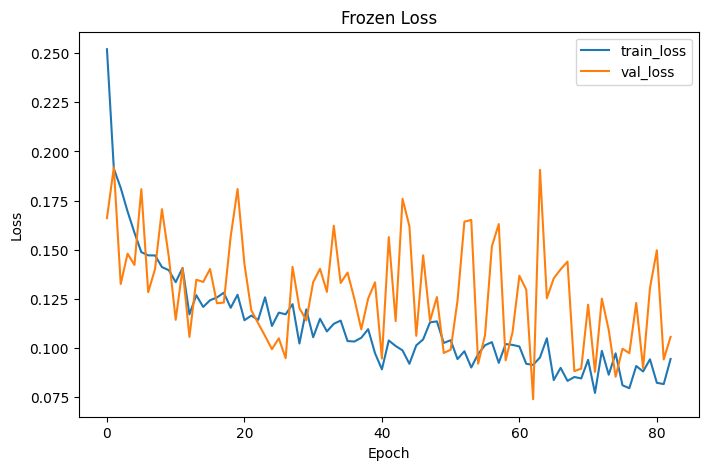

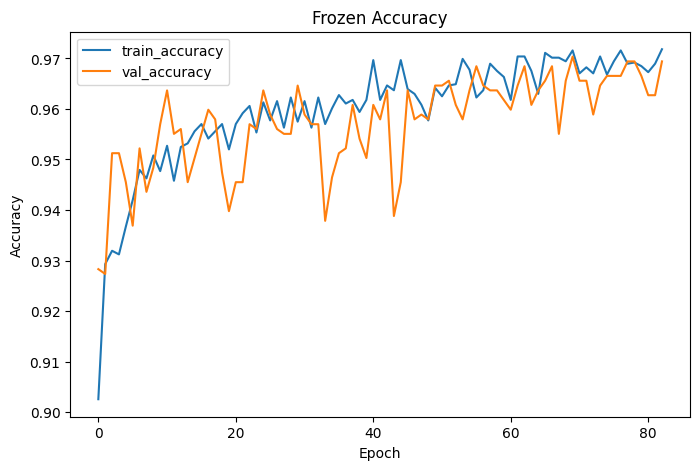

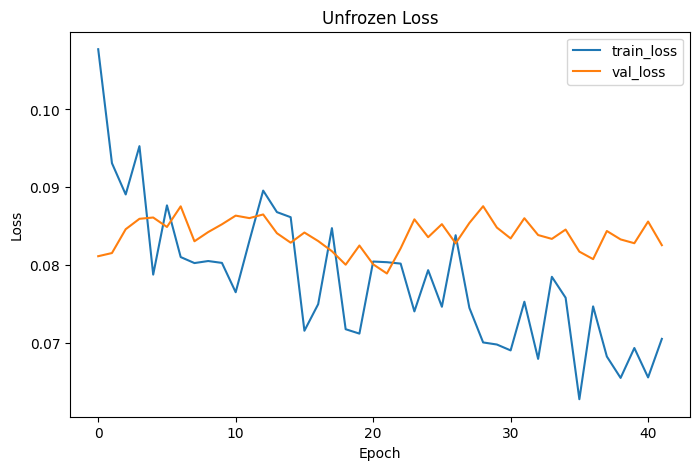

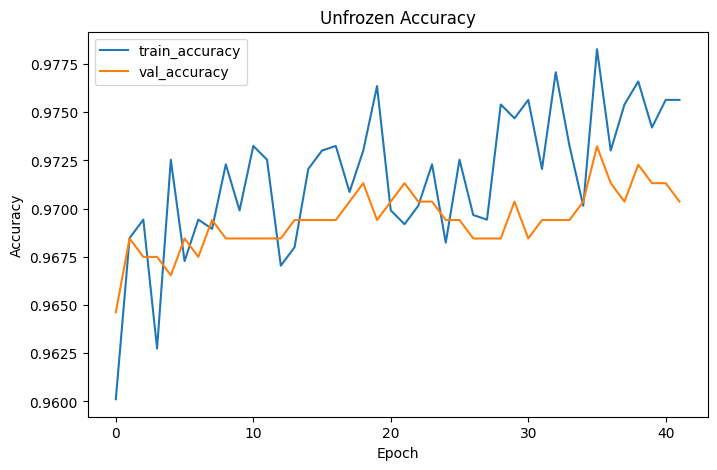

In [ ]:
# plot
def plot_history(history, title_prefix=""):
    hist = history.history

    plt.figure(figsize=(8, 5))
    plt.plot(hist["loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{title_prefix} Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(hist["accuracy"], label="train_accuracy")
    plt.plot(hist["val_accuracy"], label="val_accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"{title_prefix} Accuracy")
    plt.legend()
    plt.show()


plot_history(history_frozen, "Frozen")
plot_history(history_unfrozen, "Unfrozen")

In [ ]:
# metrics
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

def evaluate_model_metrics(model, dataset, class_names):
    y_true = []
    y_pred = []
    y_probs = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        pred_classes = np.argmax(preds, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(pred_classes)
        y_probs.extend(preds[:, 1])   # pneumonia probability if class 1

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    y_probs = np.array(y_probs)

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print()

    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))
    print()

    print("Precision:", precision_score(y_true, y_pred))
    print("Recall:", recall_score(y_true, y_pred))
    print("F1:", f1_score(y_true, y_pred))

In [ ]:
# evalutate the model with a matrix report

from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model_with_report(model, dataset, class_names):
    y_true = []
    y_pred = []

    for images, labels in dataset:
        preds = model.predict(images, verbose=0)
        pred_classes = np.argmax(preds, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(pred_classes)

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    print()
    print("Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))


evaluate_model_with_report(model1_unfrozen, test_ds, class_names)


Confusion Matrix:
[[128 106]
 [  5 385]]

Classification Report:
              precision    recall  f1-score   support

      NORMAL       0.96      0.55      0.70       234
   PNEUMONIA       0.78      0.99      0.87       390

    accuracy                           0.82       624
   macro avg       0.87      0.77      0.79       624
weighted avg       0.85      0.82      0.81       624



# Grad cam

In [ ]:
# grad cam helpers
def get_one_image(dataset):
    images, labels = next(iter(dataset))
    return images[0], labels[0]

def make_gradcam_heatmap(model, image_batch, class_index=None, layer_name="feat_maps"):
    grad_model = tf.keras.models.Model(
        inputs=model.input,
        outputs=[model.get_layer(layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(image_batch, training=False)

        if class_index is None:
            class_index = tf.argmax(predictions[0])

        class_channel = predictions[:, class_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = tf.reduce_sum(conv_outputs * pooled_grads, axis=-1)

    heatmap = tf.maximum(heatmap, 0)

    max_val = tf.reduce_max(heatmap)
    if max_val > 0:
        heatmap = heatmap / max_val

    return heatmap.numpy(), predictions.numpy()

def display_gradcam(image, heatmap, label=None, pred_probs=None, class_names=None):
    image_np = image.numpy()
    display_img = np.clip(image_np / 255.0, 0.0, 1.0)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(display_img)
    title = "Original"
    if label is not None and class_names is not None:
        title += f"\nTrue: {class_names[int(label.numpy())]}"
    plt.title(title)
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap="jet")
    plt.title("Grad-CAM Heatmap")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(display_img)
    plt.imshow(heatmap, cmap="jet", alpha=0.4)
    overlay_title = "Overlay"
    if pred_probs is not None and class_names is not None:
        pred_idx = np.argmax(pred_probs[0])
        conf = pred_probs[0][pred_idx]
        overlay_title += f"\nPred: {class_names[pred_idx]} ({conf:.3f})"
    plt.title(overlay_title)
    plt.axis("off")

    plt.tight_layout()
    plt.show()

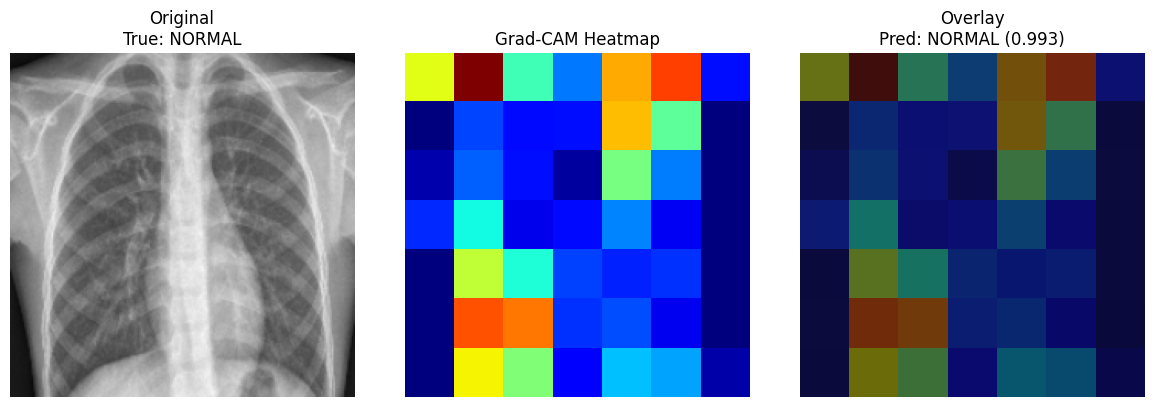

In [ ]:
image, label = get_one_image(test_ds)
image_batch = tf.expand_dims(image, axis=0)

heatmap, preds = make_gradcam_heatmap(
    model=model1_frozen,
    image_batch=image_batch,
    class_index=None,
    layer_name="feat_maps"
)

display_gradcam(
    image=image,
    heatmap=heatmap,
    label=label,
    pred_probs=preds,
    class_names=class_names
)

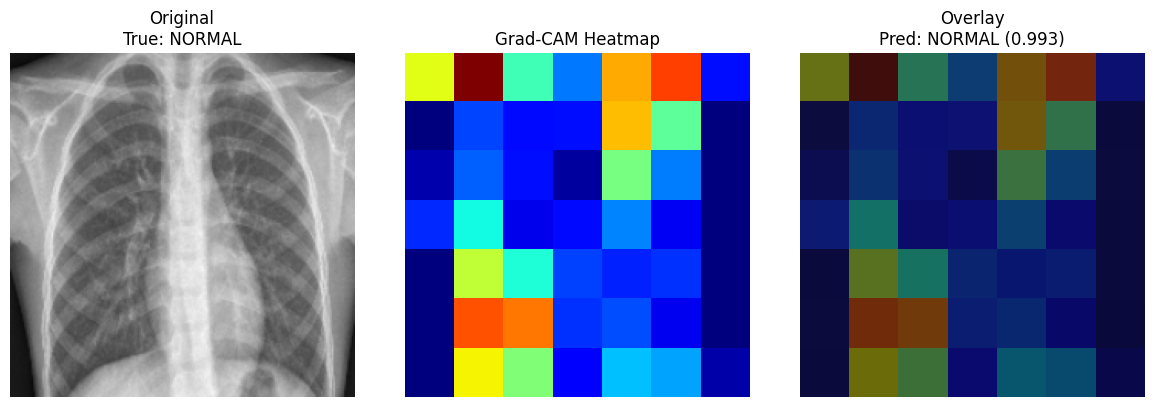

In [ ]:
image, label = get_one_image(test_ds)
image_batch = tf.expand_dims(image, axis=0)

heatmap2, preds2 = make_gradcam_heatmap(
    model=model1_unfrozen,
    image_batch=image_batch,
    class_index=None,
    layer_name="feat_maps"
)

display_gradcam(
    image=image,
    heatmap=heatmap2,
    label=label,
    pred_probs=preds2,
    class_names=class_names
)

#Part two grid original image with heatmap

In [ ]:
# resize the heatmap and grid it into 20 parts
def resize_heatmap_to_image(heatmap, image):
    if hasattr(image, "numpy"):
        image = image.numpy()

    h, w = image.shape[:2]

    heatmap_tf = tf.convert_to_tensor(heatmap, dtype=tf.float32)
    heatmap_tf = tf.expand_dims(heatmap_tf, axis=-1)
    heatmap_tf = tf.expand_dims(heatmap_tf, axis=0)

    resized = tf.image.resize(heatmap_tf, size=(h, w), method="bilinear")
    resized = tf.squeeze(resized).numpy()

    resized = np.maximum(resized, 0)
    max_val = resized.max()
    if max_val > 0:
        resized = resized / max_val

    return resized

def score_heatmap_grid(resized_heatmap, rows=4, cols=5):
    h, w = resized_heatmap.shape
    cell_h = h // rows
    cell_w = w // cols

    cells = []

    for r in range(rows):
        for c in range(cols):
            y1 = r * cell_h
            y2 = (r + 1) * cell_h if r < rows - 1 else h

            x1 = c * cell_w
            x2 = (c + 1) * cell_w if c < cols - 1 else w

            cell_region = resized_heatmap[y1:y2, x1:x2]
            score = float(np.mean(cell_region))

            cells.append({
                "row": r,
                "col": c,
                "x1": x1,
                "y1": y1,
                "x2": x2,
                "y2": y2,
                "score": score
            })

    return cells

def select_top_cells(cells, top_k=4):
    cells_sorted = sorted(cells, key=lambda x: x["score"], reverse=True)
    return cells_sorted[:top_k]

def merge_cells_to_box(selected_cells):
    x1 = min(cell["x1"] for cell in selected_cells)
    y1 = min(cell["y1"] for cell in selected_cells)
    x2 = max(cell["x2"] for cell in selected_cells)
    y2 = max(cell["y2"] for cell in selected_cells)
    return x1, y1, x2, y2

In [ ]:
# box expansion and crop
def expand_box(box, image_shape, pad_ratio=0.10):
    h, w = image_shape[:2]
    x1, y1, x2, y2 = box

    box_w = x2 - x1
    box_h = y2 - y1

    pad_x = int(box_w * pad_ratio)
    pad_y = int(box_h * pad_ratio)

    new_x1 = max(0, x1 - pad_x)
    new_y1 = max(0, y1 - pad_y)
    new_x2 = min(w, x2 + pad_x)
    new_y2 = min(h, y2 + pad_y)

    return (new_x1, new_y1, new_x2, new_y2)

def crop_image_with_box(image, box):
    if hasattr(image, "numpy"):
        image = image.numpy()

    x1, y1, x2, y2 = box
    crop = image[y1:y2, x1:x2]
    return crop

def crop_and_resize_for_model2(image, box, target_size=(224, 224)):
    if hasattr(image, "numpy"):
        image = image.numpy()

    x1, y1, x2, y2 = box
    crop_np = image[y1:y2, x1:x2]

    crop_tensor = tf.convert_to_tensor(crop_np, dtype=tf.float32)
    crop_resized = tf.image.resize(crop_tensor, target_size)

    return crop_np, crop_resized

In [ ]:
# view grid
def visualize_grid_selection(image, resized_heatmap, cells, selected_cells, merged_box, class_name=None):
    if hasattr(image, "numpy"):
        image = image.numpy()

    display_img = np.clip(image / 255.0, 0.0, 1.0)

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    axes[0].imshow(display_img)
    axes[0].set_title("Original Image" if class_name is None else f"Original Image\n{class_name}")
    axes[0].axis("off")

    axes[1].imshow(display_img)
    axes[1].imshow(resized_heatmap, cmap="jet", alpha=0.4)
    axes[1].set_title("Resized Grad-CAM Overlay")
    axes[1].axis("off")

    axes[2].imshow(display_img)
    axes[2].imshow(resized_heatmap, cmap="jet", alpha=0.25)
    axes[2].set_title("Grid Selection + Merged Box")
    axes[2].axis("off")

    for cell in cells:
        rect = patches.Rectangle(
            (cell["x1"], cell["y1"]),
            cell["x2"] - cell["x1"],
            cell["y2"] - cell["y1"],
            linewidth=0.8,
            edgecolor="white",
            facecolor="none",
            alpha=0.5
        )
        axes[2].add_patch(rect)

    for cell in selected_cells:
        rect = patches.Rectangle(
            (cell["x1"], cell["y1"]),
            cell["x2"] - cell["x1"],
            cell["y2"] - cell["y1"],
            linewidth=2,
            edgecolor="yellow",
            facecolor="none"
        )
        axes[2].add_patch(rect)

        axes[2].text(
            cell["x1"] + 3,
            cell["y1"] + 12,
            f'{cell["score"]:.2f}',
            color="yellow",
            fontsize=8,
            bbox=dict(facecolor="black", alpha=0.5, pad=1)
        )

    x1, y1, x2, y2 = merged_box
    merged_rect = patches.Rectangle(
        (x1, y1),
        x2 - x1,
        y2 - y1,
        linewidth=2.5,
        edgecolor="red",
        facecolor="none"
    )
    axes[2].add_patch(merged_rect)

    plt.tight_layout()
    plt.show()

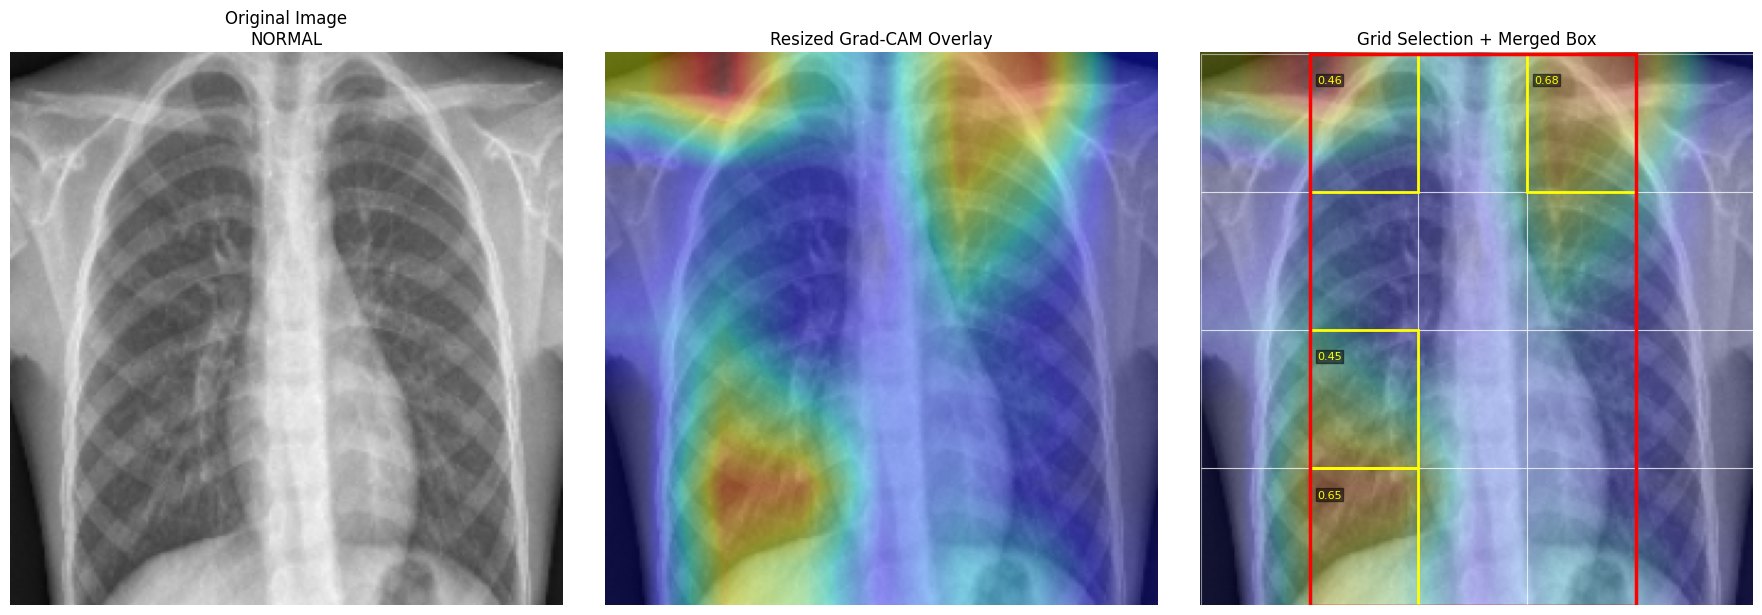

Merged box: (44, 0, 176, 224)
Crop shape: (224, 132, 3)


In [ ]:
resized_heatmap = resize_heatmap_to_image(heatmap, image)
cells = score_heatmap_grid(resized_heatmap, rows=4, cols=5)
selected_cells = select_top_cells(cells, top_k=4)
merged_box = merge_cells_to_box(selected_cells)

class_name = class_names[int(label.numpy())]

visualize_grid_selection(
    image=image,
    resized_heatmap=resized_heatmap,
    cells=cells,
    selected_cells=selected_cells,
    merged_box=merged_box,
    class_name=class_name
)

crop = crop_image_with_box(image, merged_box)
print("Merged box:", merged_box)
print("Crop shape:", crop.shape)

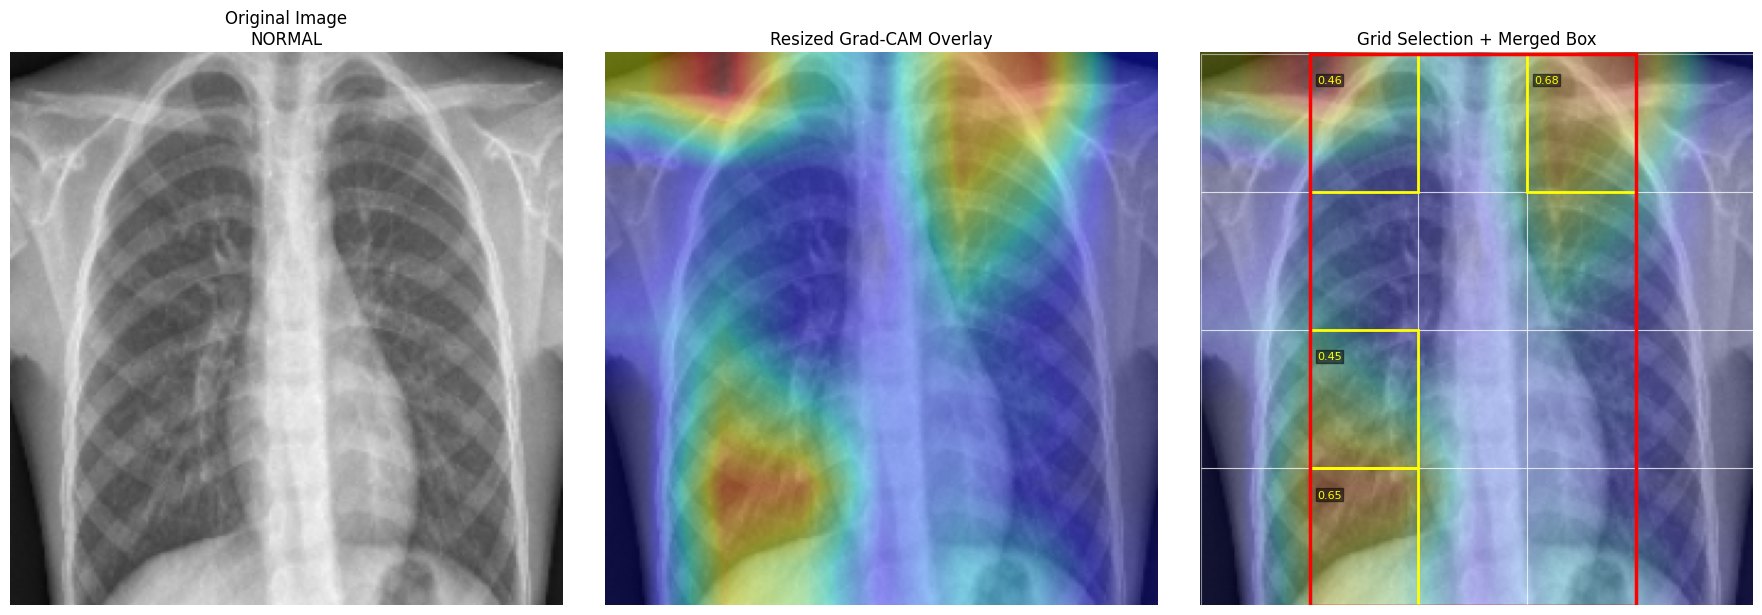

Merged box: (44, 0, 176, 224)
Crop shape: (224, 132, 3)


In [ ]:
resized_heatmap = resize_heatmap_to_image(heatmap2, image)
cells = score_heatmap_grid(resized_heatmap, rows=4, cols=5)
selected_cells = select_top_cells(cells, top_k=4)
merged_box = merge_cells_to_box(selected_cells)

class_name = class_names[int(label.numpy())]

visualize_grid_selection(
    image=image,
    resized_heatmap=resized_heatmap,
    cells=cells,
    selected_cells=selected_cells,
    merged_box=merged_box,
    class_name=class_name
)

crop = crop_image_with_box(image, merged_box)
print("Merged box:", merged_box)
print("Crop shape:", crop.shape)

In [ ]:

# single image prediction
def predict_single_image(model, image_tensor):
    image_batch = tf.expand_dims(image_tensor, axis=0)
    preds = model(image_batch, training=False).numpy()
    return preds
#  Stage 2 helper
def run_model2_on_crop(model2, crop_resized, layer_name="feat_maps"):
    crop_batch = tf.expand_dims(crop_resized, axis=0)

    preds = model2(crop_batch, training=False).numpy()

    heatmap, _ = make_gradcam_heatmap(
        model=model2,
        image_batch=crop_batch,
        class_index=None,
        layer_name=layer_name
    )

    return preds, heatmap

#model two

In [ ]:
#  Save crops for Model 2 dataset
def save_image_uint8(image_np, save_path):
    image_np = np.clip(image_np, 0, 255).astype(np.uint8)
    img = Image.fromarray(image_np)
    img.save(save_path)
    print(f"Saved image to {save_path}")

def generate_crop_from_model1(
    image,
    model1,
    model1_layer="feat_maps",
    rows=4,
    cols=5,
    top_k=4,
    pad_ratio=0.12,
    force_class_index=1
):
    image_batch = tf.expand_dims(image, axis=0)

    preds1 = model1(image_batch, training=False).numpy()
    pred1_idx = int(np.argmax(preds1[0]))
    pred1_conf = float(preds1[0][pred1_idx])
    pneumonia_prob = float(preds1[0][1])

    heatmap1, _ = make_gradcam_heatmap(
        model=model1,
        image_batch=image_batch,
        class_index=force_class_index,
        layer_name=model1_layer
    )

    resized_heatmap1 = resize_heatmap_to_image(heatmap1, image)

    cells = score_heatmap_grid(resized_heatmap1, rows=rows, cols=cols)
    selected_cells = select_top_cells(cells, top_k=top_k)
    merged_box = merge_cells_to_box(selected_cells)
    expanded_box = expand_box(
        merged_box,
        image_shape=image.shape,
        pad_ratio=pad_ratio
    )

    crop_np, crop_resized = crop_and_resize_for_model2(
        image=image,
        box=expanded_box,
        target_size=(224, 224)
    )

    info = {
        "stage1_probs": preds1[0],
        "stage1_pred_idx": pred1_idx,
        "stage1_pred_conf": pred1_conf,
        "pneumonia_prob": pneumonia_prob,
        "heatmap": heatmap1,
        "resized_heatmap": resized_heatmap1,
        "cells": cells,
        "selected_cells": selected_cells,
        "merged_box": merged_box,
        "expanded_box": expanded_box
    }

    return crop_np, info
def make_model2_output_dirs(output_root, class_names):
    for split in ["train", "val", "test"]:
        for class_name in class_names:
            os.makedirs(os.path.join(output_root, split, class_name), exist_ok=True)

def save_crops_for_split(
    dataset,
    split_name,
    output_root,
    model1,
    class_names,
    model1_layer="feat_maps",
    rows=4,
    cols=5,
    top_k=4,
    pad_ratio=0.12,
    max_images=None
):
    count = 0

    for batch_idx, (images, labels) in enumerate(dataset):
        images_np = images.numpy()
        labels_np = labels.numpy()

        for i in range(len(images_np)):
            image = tf.convert_to_tensor(images_np[i], dtype=tf.float32)
            label_idx = int(labels_np[i])
            class_name = class_names[label_idx]

            crop_np, info = generate_crop_from_model1(
                image=image,
                model1=model1,
                model1_layer=model1_layer,
                rows=rows,
                cols=cols,
                top_k=top_k,
                pad_ratio=pad_ratio,
                force_class_index=1
            )

            save_name = f"{split_name}_{count:05d}.png"
            save_path = os.path.join(output_root, split_name, class_name, save_name)

            save_image_uint8(crop_np, save_path)

            count += 1

            if count % 100 == 0:
                print(f"{split_name}: saved {count} crops")

            if max_images is not None and count >= max_images:
                print(f"{split_name}: reached max_images={max_images}")
                return

    print(f"{split_name}: finished, total saved = {count}")


def build_model2_crop_dataset(
    output_root,
    model1,
    train_ds,
    val_ds,
    test_ds,
    class_names,
    model1_layer="feat_maps",
    rows=4,
    cols=5,
    top_k=4,
    pad_ratio=0.12,
    max_train=None,
    max_val=None,
    max_test=None
):
    make_model2_output_dirs(output_root, class_names)

    save_crops_for_split(
        dataset=train_ds,
        split_name="train",
        output_root=output_root,
        model1=model1,
        class_names=class_names,
        model1_layer=model1_layer,
        rows=rows,
        cols=cols,
        top_k=top_k,
        pad_ratio=pad_ratio,
        max_images=max_train
    )

    save_crops_for_split(
        dataset=val_ds,
        split_name="val",
        output_root=output_root,
        model1=model1,
        class_names=class_names,
        model1_layer=model1_layer,
        rows=rows,
        cols=cols,
        top_k=top_k,
        pad_ratio=pad_ratio,
        max_images=max_val
    )

    save_crops_for_split(
        dataset=test_ds,
        split_name="test",
        output_root=output_root,
        model1=model1,
        class_names=class_names,
        model1_layer=model1_layer,
        rows=rows,
        cols=cols,
        top_k=top_k,
        pad_ratio=pad_ratio,
        max_images=max_test
    )
MODEL2_DATA_ROOT = "/content/model2_crops"

# first do a small test
build_model2_crop_dataset(
    output_root=MODEL2_DATA_ROOT,
    model1=model1_frozen,
    train_ds=train_ds,
    val_ds=val_ds,
    test_ds=test_ds,
    class_names=class_names,
    model1_layer="feat_maps",
    rows=4,
    cols=5,
    top_k=4,
    pad_ratio=0.12,
    max_train=50,
    max_val=20,
    max_test=20
)

Saved image to /content/model2_crops/train/NORMAL/train_00000.png
Saved image to /content/model2_crops/train/NORMAL/train_00001.png
Saved image to /content/model2_crops/train/PNEUMONIA/train_00002.png
Saved image to /content/model2_crops/train/NORMAL/train_00003.png
Saved image to /content/model2_crops/train/NORMAL/train_00004.png
Saved image to /content/model2_crops/train/PNEUMONIA/train_00005.png
Saved image to /content/model2_crops/train/PNEUMONIA/train_00006.png
Saved image to /content/model2_crops/train/PNEUMONIA/train_00007.png
Saved image to /content/model2_crops/train/PNEUMONIA/train_00008.png
Saved image to /content/model2_crops/train/NORMAL/train_00009.png
Saved image to /content/model2_crops/train/NORMAL/train_00010.png
Saved image to /content/model2_crops/train/PNEUMONIA/train_00011.png
Saved image to /content/model2_crops/train/PNEUMONIA/train_00012.png
Saved image to /content/model2_crops/train/PNEUMONIA/train_00013.png
Saved image to /content/model2_crops/train/PNEUMONIA

In [ ]:
MODEL2_DATA_ROOT = "/content/model2_crops"

train2_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(MODEL2_DATA_ROOT, "train"),
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val2_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(MODEL2_DATA_ROOT, "val"),
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True
)

test2_ds_raw = tf.keras.utils.image_dataset_from_directory(
    os.path.join(MODEL2_DATA_ROOT, "test"),
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 50 files belonging to 2 classes.
Found 20 files belonging to 2 classes.
Found 20 files belonging to 2 classes.


In [ ]:
train2_ds = train2_ds_raw.map(preprocess_train, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
val2_ds = val2_ds_raw.map(preprocess_base, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test2_ds = test2_ds_raw.map(preprocess_base, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

In [ ]:
# train model 2
model2s_frozen, base_model2 = build_model1_efficientnet_b0(
    input_shape=(224, 224, 3),
    num_classes=2
)

model2s_frozen.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
history2_frozen = model2s_frozen.fit(
    train2_ds,
    validation_data=val2_ds,
    epochs=100,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=20,
            restore_best_weights=True
        )
    ]
)

Epoch 1/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 54s 32s/step - accuracy: 0.4800 - loss: 0.8829 - val_accuracy: 0.7500 - val_loss: 0.6407
Epoch 2/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 266ms/step - accuracy: 0.8000 - loss: 0.4704 - val_accuracy: 0.7500 - val_loss: 0.6023
Epoch 3/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 282ms/step - accuracy: 0.7800 - loss: 0.4331 - val_accuracy: 0.7500 - val_loss: 0.5691
Epoch 4/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step - accuracy: 0.8000 - loss: 0.3629 - val_accuracy: 0.7500 - val_loss: 0.5385
Epoch 5/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 262ms/step - accuracy: 0.8000 - loss: 0.4396 - val_accuracy: 0.8500 - val_loss: 0.5125
Epoch 6/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 265ms/step - accuracy: 0.8600 - loss: 0.2752 - val_accuracy: 0.8500 - val_loss: 0.4901
Epoch 7/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 268ms/step - accuracy: 0.8800 - loss: 0.2754 - val_accuracy: 0.9000 - val_loss: 0.4708
Epoch 8/100
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 267ms/step - accuracy: 0.8400 - loss: 0.3945 - val_accuracy: 0.9000 - va

In [ ]:
base_model2.trainable = True

for layer in base_model2.layers[:-20]:
    layer.trainable = False

model2s_frozen.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model2s_unfrozen = model2s_frozen

history2_unfrozen = model2s_unfrozen.fit(
    train2_ds,
    validation_data=val2_ds,
    epochs=20,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True
        )
    ]
)

Epoch 1/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 50s 22s/step - accuracy: 0.9000 - loss: 0.2538 - val_accuracy: 0.8500 - val_loss: 0.2618
Epoch 2/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step - accuracy: 0.8400 - loss: 0.4466 - val_accuracy: 0.8500 - val_loss: 0.2652
Epoch 3/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 192ms/step - accuracy: 0.9200 - loss: 0.1907 - val_accuracy: 0.8500 - val_loss: 0.2678
Epoch 4/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 188ms/step - accuracy: 0.9000 - loss: 0.2541 - val_accuracy: 0.8500 - val_loss: 0.2713
Epoch 5/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 190ms/step - accuracy: 0.9200 - loss: 0.1727 - val_accuracy: 0.8500 - val_loss: 0.2734
Epoch 6/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - accuracy: 0.9200 - loss: 0.4436 - val_accuracy: 0.8500 - val_loss: 0.2761
Epoch 7/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 193ms/step - accuracy: 0.8600 - loss: 0.4548 - val_accuracy: 0.8500 - val_loss: 0.2784
Epoch 8/20
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 189ms/step - accuracy: 0.8800 - loss: 0.5239 - val_accuracy: 0.8500 - val_loss: 

In [ ]:
evaluate_model_metrics(model2_unfrozen, test2_ds, class_names)

#Run full pipeline two model approach

In [ ]:
def two_stage_pipeline(
    image,
    model1,
    model2,
    model1_layer="feat_maps",
    model2_layer="feat_maps",
    threshold=0.60,
    rows=4,
    cols=5,
    top_k=4,
    pad_ratio=0.10,
    class_names=None
):
    preds1 = predict_single_image(model1, image)
    pred1_idx = int(np.argmax(preds1[0]))
    pred1_conf = float(preds1[0][pred1_idx])

    pneumonia_prob = float(preds1[0][1])  # class 1 assumed pneumonia

    results = {
        "stage1_pred_idx": pred1_idx,
        "stage1_pred_conf": pred1_conf,
        "stage1_probs": preds1[0],
        "pneumonia_prob": pneumonia_prob,
        "ran_stage2": False
    }

    if pneumonia_prob < threshold:
        return results

    image_batch = tf.expand_dims(image, axis=0)

    heatmap1, _ = make_gradcam_heatmap(
        model=model1,
        image_batch=image_batch,
        class_index=1,
        layer_name=model1_layer
    )

    resized_heatmap1 = resize_heatmap_to_image(heatmap1, image)

    cells = score_heatmap_grid(resized_heatmap1, rows=rows, cols=cols)
    selected_cells = select_top_cells(cells, top_k=top_k)
    merged_box = merge_cells_to_box(selected_cells)
    expanded_box = expand_box(
        merged_box,
        image_shape=image.shape,
        pad_ratio=pad_ratio
    )

    crop_np, crop_resized = crop_and_resize_for_model2(image, expanded_box)

    preds2, heatmap2 = run_model2_on_crop(
        model2=model2,
        crop_resized=crop_resized,
        layer_name=model2_layer
    )

    pred2_idx = int(np.argmax(preds2[0]))
    pred2_conf = float(preds2[0][pred2_idx])

    results.update({
        "ran_stage2": True,
        "stage1_heatmap": heatmap1,
        "stage1_resized_heatmap": resized_heatmap1,
        "cells": cells,
        "selected_cells": selected_cells,
        "merged_box": merged_box,
        "expanded_box": expanded_box,
        "crop_np": crop_np,
        "crop_resized": crop_resized.numpy(),
        "stage2_probs": preds2[0],
        "stage2_pred_idx": pred2_idx,
        "stage2_pred_conf": pred2_conf,
        "stage2_heatmap": heatmap2
    })

    return results

In [ ]:
def visualize_two_stage_result(result, image, class_names=None):
    if hasattr(image, "numpy"):
        image_np = image.numpy()
    else:
        image_np = image

    display_img = np.clip(image_np / 255.0, 0.0, 1.0)

    if not result["ran_stage2"]:
        plt.figure(figsize=(6, 6))
        plt.imshow(display_img)
        title = f"Stage 1 Only\nPneumonia prob: {result['pneumonia_prob']:.3f}"
        if class_names is not None:
            title += f"\nPred: {class_names[result['stage1_pred_idx']]}"
        plt.title(title)
        plt.axis("off")
        plt.show()
        return

    fig, axes = plt.subplots(1, 4, figsize=(22, 6))

    axes[0].imshow(display_img)
    axes[0].set_title("Original")
    axes[0].axis("off")

    axes[1].imshow(display_img)
    axes[1].imshow(result["stage1_resized_heatmap"], cmap="jet", alpha=0.4)
    axes[1].set_title(f"Stage 1 Grad-CAM\nPneumonia prob: {result['pneumonia_prob']:.3f}")
    axes[1].axis("off")

    axes[2].imshow(display_img)
    axes[2].imshow(result["stage1_resized_heatmap"], cmap="jet", alpha=0.25)
    axes[2].set_title("Selected Region")
    axes[2].axis("off")

    x1, y1, x2, y2 = result["expanded_box"]
    rect = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2.5, edgecolor="red", facecolor="none"
    )
    axes[2].add_patch(rect)

    crop_display = np.clip(result["crop_np"] / 255.0, 0.0, 1.0)
    heatmap2_resized = resize_heatmap_to_image(result["stage2_heatmap"], result["crop_np"])

    axes[3].imshow(crop_display)
    axes[3].imshow(heatmap2_resized, cmap="jet", alpha=0.4)
    title = "Stage 2 Crop"
    if class_names is not None:
        title += f"\nPred: {class_names[result['stage2_pred_idx']]}"
    title += f" ({result['stage2_pred_conf']:.3f})"
    axes[3].set_title(title)
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

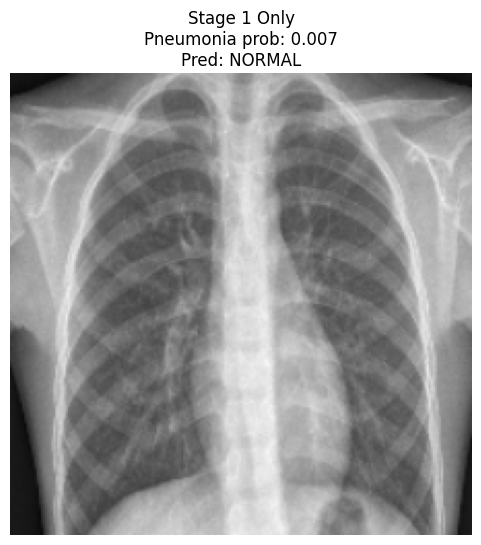

Ran stage 2: False
Stage 1 probs: [0.9926156 0.0073844]


In [ ]:
image, label = get_one_image(test_ds)

result = two_stage_pipeline(
    image=image,
    model1=model1_frozen,
    model2=model2s_frozen,   # temporary placeholder until real Model 2 is trained
    threshold=0.60,
    rows=4,
    cols=5,
    top_k=4,
    pad_ratio=0.12,
    class_names=class_names
)

visualize_two_stage_result(result, image, class_names=class_names)
print("Ran stage 2:", result["ran_stage2"])
print("Stage 1 probs:", result["stage1_probs"])
if result["ran_stage2"]:
    print("Stage 2 probs:", result["stage2_probs"])

#Save for model 2

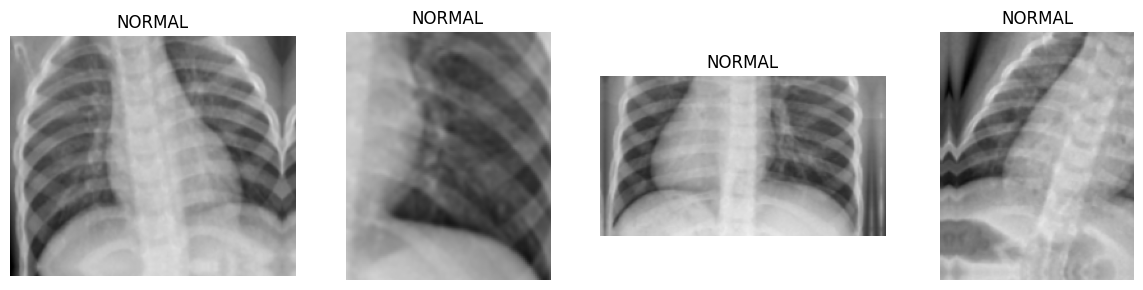

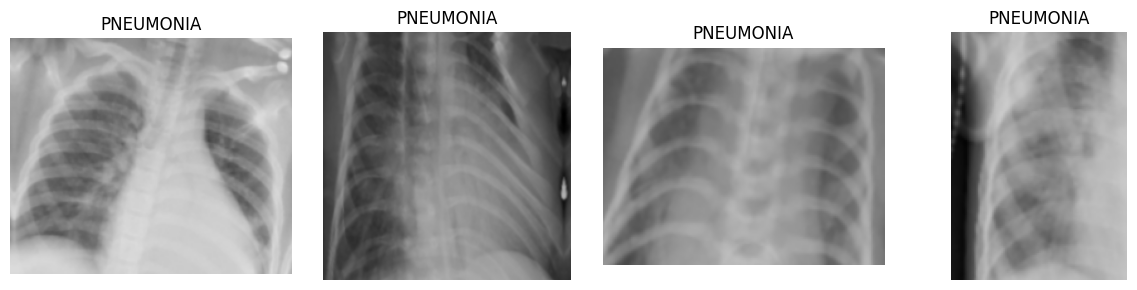

In [ ]:
# preivew model 2 crops
def show_saved_crops(output_root, split, class_name, n=4):
    folder = os.path.join(output_root, split, class_name)
    files = sorted(os.listdir(folder))[:n]

    plt.figure(figsize=(12, 3))
    for i, fname in enumerate(files):
        img = Image.open(os.path.join(folder, fname))
        plt.subplot(1, n, i + 1)
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")
    plt.tight_layout()
    plt.show()
show_saved_crops(MODEL2_DATA_ROOT, "train", class_names[0], n=4)
show_saved_crops(MODEL2_DATA_ROOT, "train", class_names[1], n=4)

In [ ]:
# load a model for later
model_loaded = keras.models.load_model(
    "/content/model1_unfrozen.keras",
    safe_mode=False
)

model_loaded.summary()

ValueError: File not found: filepath=/content/model1_unfrozen.keras. Please ensure the file is an accessible `.keras` zip file.

In [ ]:
# unfrozen_test_results = model2s_frozen.evaluate(test_ds, return_dict=True)
print("frozen model test results:")
# print(unfrozen_test_results)

model2s_frozen.save("model2_efficent.keras")
model2s_frozen.summary()
# print("hi")

frozen model test results:


Model: "model1_efficientnetb0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ image_input (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feat_maps (Lambda)              │ (None, 7, 7, 1280)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_head (BatchNormalization)    │ (None, 1280)           │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_128 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 2)              │           130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,869,387 (30.02 MB)

 Trainable params: 1,722,738 (6.57 MB)

 Non-trainable params: 2,701,171 (10.30 MB)

 Optimizer params: 3,445,478 (13.14 MB)